<a href="https://colab.research.google.com/github/noorsubhi445-cmyk/Supermarket-Sales-Analysis/blob/main/Supermarket_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- SECTION 1: Successfully loaded SuperMarket Analysis (2).csv ---
Head:
     Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00

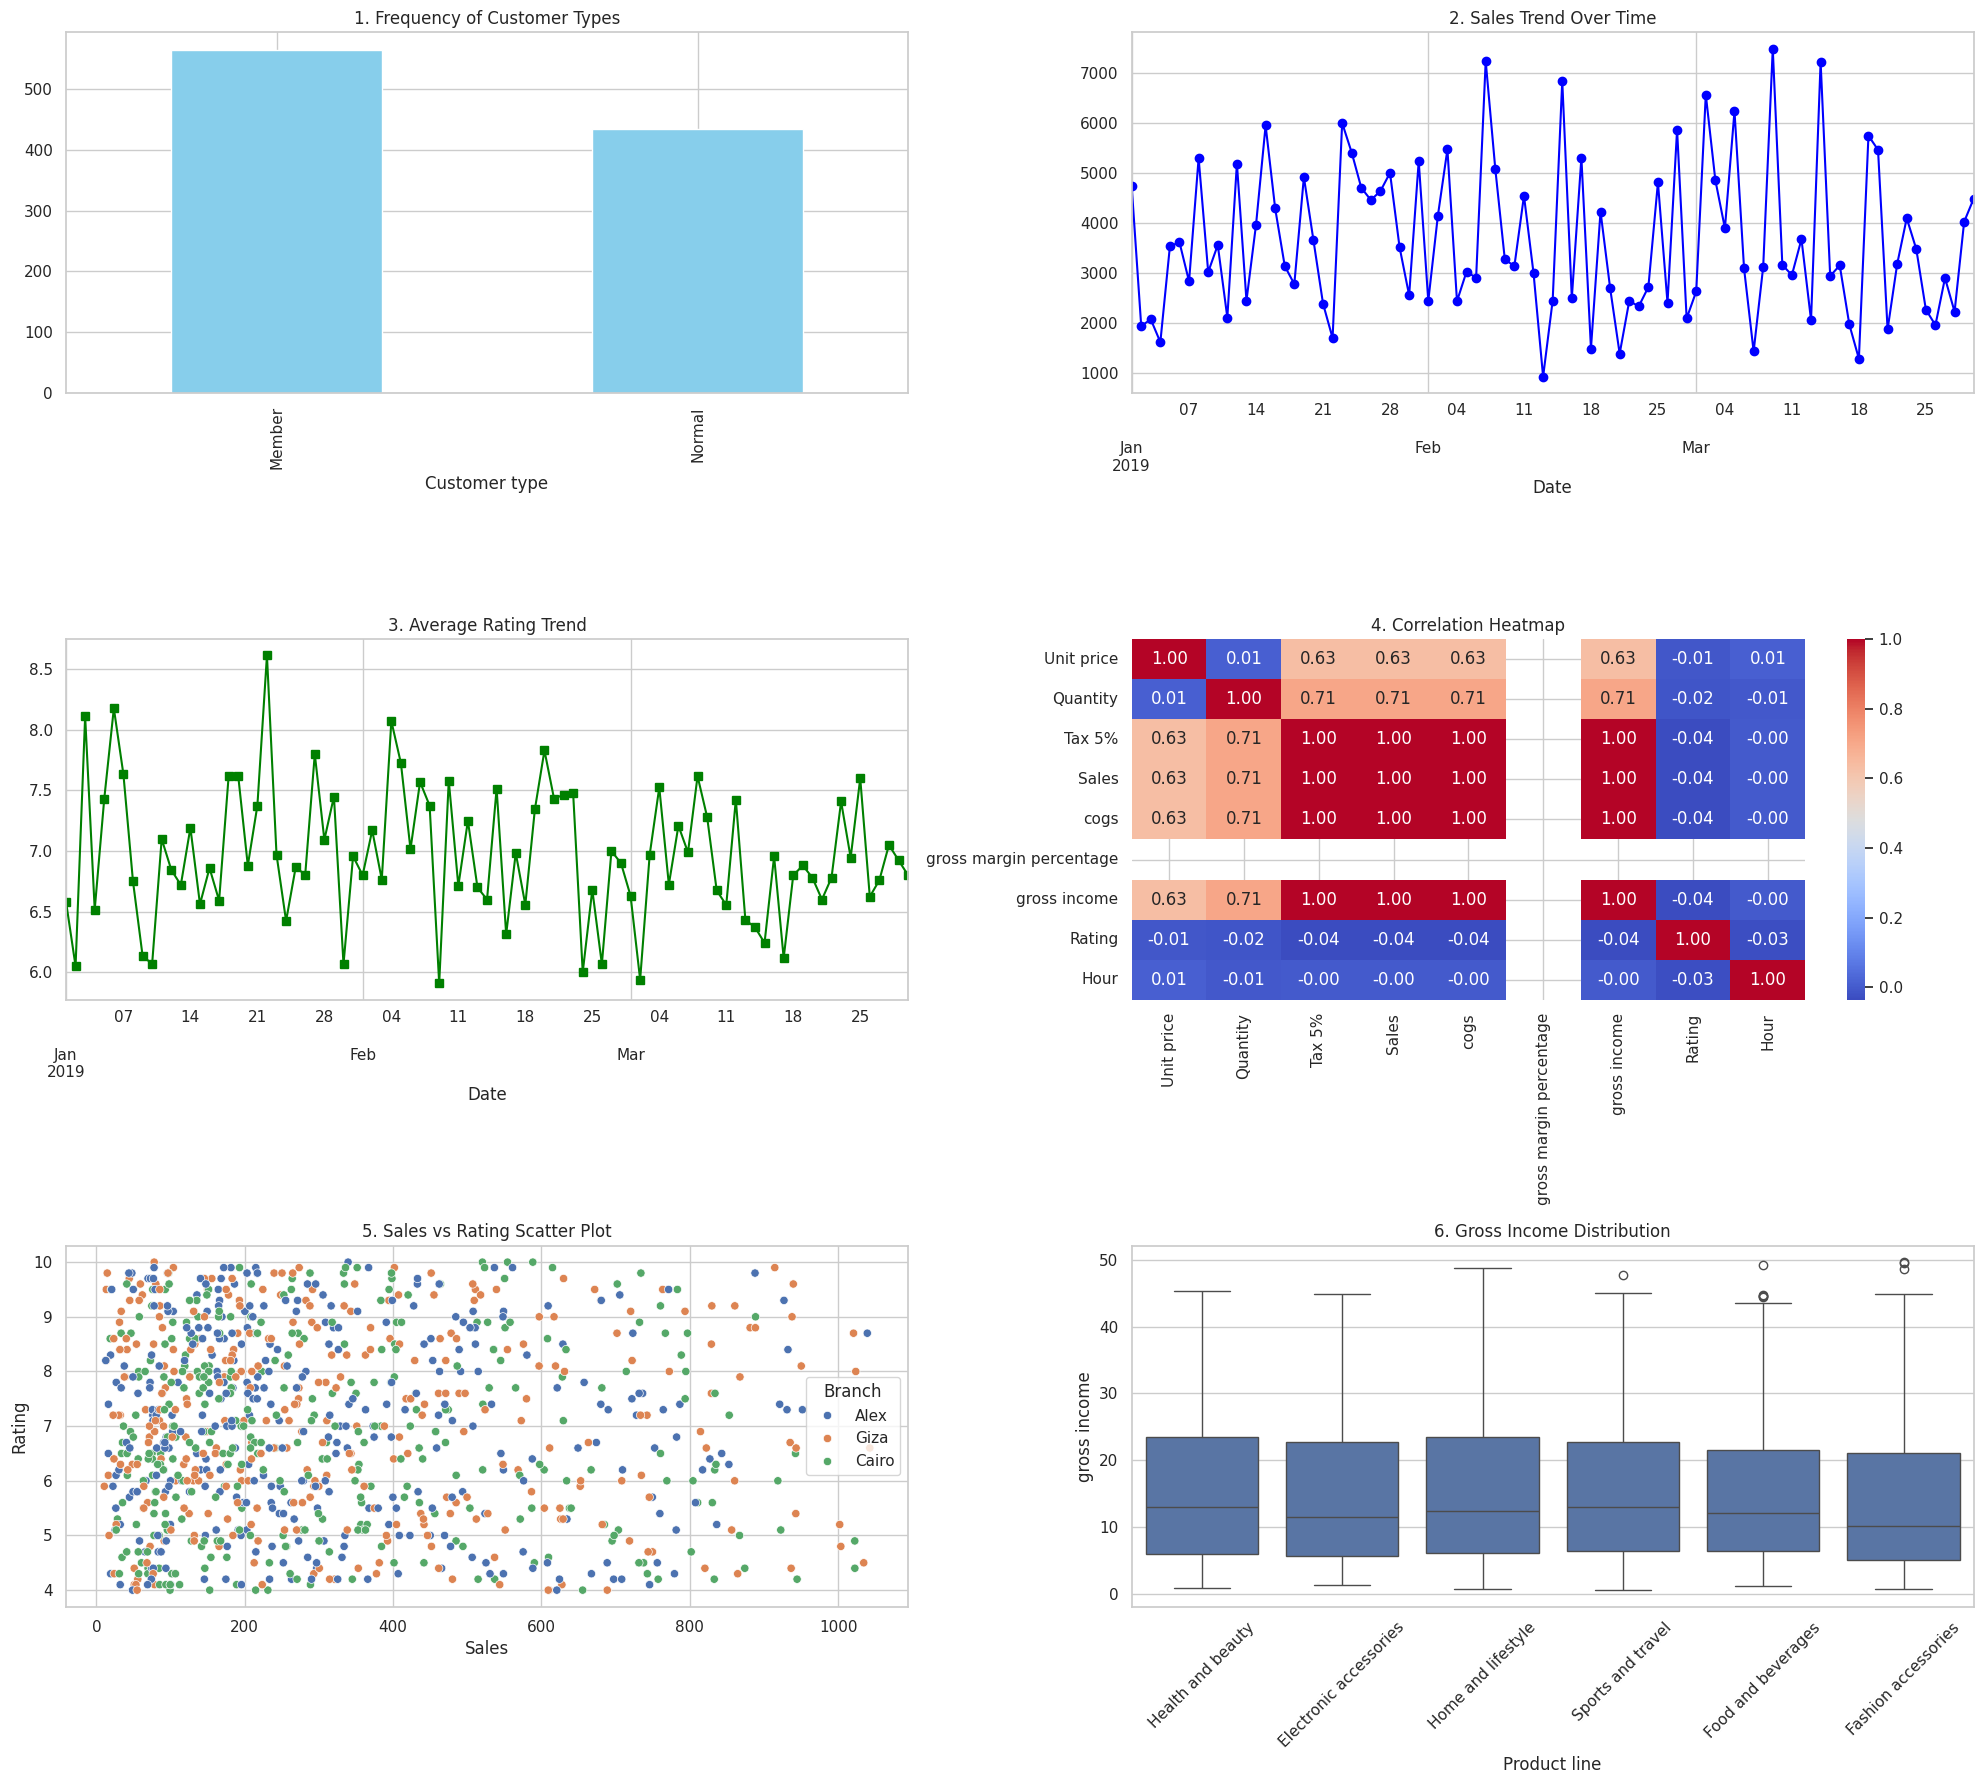


SECTION 6: ANSWERS TO PROJECT QUESTIONS
Q1: Highest Revenue Branch: Giza ($110568.71)
Reason: Higher customer traffic and larger average transaction sizes.

Q2: Total Sales by Customer Type:
Customer type
Member    189694.764
Normal    133271.985
Name: Sales, dtype: float64
Answer: Yes, Members generate higher total revenue.

Q3: Payment Usage:
Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64
Answer: Ewallet is the preferred method.

Q4: Highest Rated Product Line: Food and beverages (7.11)

Q5: Correlation (Price vs Quantity): 0.0108
Interpretation: Near zero correlation suggests that price does not impact the quantity per transaction.

--- Project Analysis Successfully Completed ---


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set(style="whitegrid")

# =========================================================
# SECTION 1: Load & Inspect Data (2 Marks)
# =========================================================
# Automatic check for file existence
file_name = "SuperMarket Analysis (2).csv"
if not os.path.exists(file_name):
    # Try the other common name if the first one isn't found
    file_name = "SuperMarket Analysis.csv"

try:
    dataset = pd.read_csv(file_name)
    print(f"--- SECTION 1: Successfully loaded {file_name} ---")
except FileNotFoundError:
    print("ERROR: File not found. Please upload the CSV to the sidebar.")

if 'dataset' in locals():
    print("Head:\n", dataset.head())
    print("\nInfo:")
    dataset.info()
    print("\nDescription:\n", dataset.describe())

    # =========================================================
    # SECTION 2: Data Cleaning (2 Marks)
    # =========================================================
    print("\n--- SECTION 2: Data Cleaning ---")
    dataset.replace(["", " ", "NA", "N/A", "nan"], pd.NA, inplace=True)

    # Cleaning Date and Time
    dataset['Date'] = pd.to_datetime(dataset['Date'])
    # Fix: Correctly parsing Time with AM/PM format
    dataset['Hour'] = pd.to_datetime(dataset['Time'], format='%I:%M:%S %p').dt.hour

    # =========================================================
    # SECTION 3 & 4: Exploratory Analysis (4 Marks)
    # =========================================================
    print("\n--- SECTION 3 & 4: Branch Statistics ---")
    branches = dataset['Branch'].to_numpy()
    sales_arr = dataset['Sales'].to_numpy()
    unique_branches = np.unique(branches)

    for b in unique_branches:
        branch_data = sales_arr[branches == b]
        print(f"Branch {b} -> Total: {np.sum(branch_data):.2f}, Mean: {np.mean(branch_data):.2f}")

    # =========================================================
    # SECTION 5: Professional Visualization (4 Marks)
    # =========================================================
    plt.figure(figsize=(20, 18))

    # 1. Customer Type Frequency
    plt.subplot(3, 2, 1)
    dataset['Customer type'].value_counts().plot(kind='bar', color='skyblue')
    plt.title("1. Frequency of Customer Types")

    # 2. Sales Trend
    plt.subplot(3, 2, 2)
    dataset.groupby('Date')['Sales'].sum().plot(marker='o', color='blue')
    plt.title("2. Sales Trend Over Time")

    # 3. Rating Trend
    plt.subplot(3, 2, 3)
    dataset.groupby('Date')['Rating'].mean().plot(marker='s', color='green')
    plt.title("3. Average Rating Trend")

    # 4. Correlation Heatmap
    plt.subplot(3, 2, 4)
    numeric_cols = dataset.select_dtypes(include=[np.number])
    sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("4. Correlation Heatmap")

    # 5. Sales vs Rating Scatter
    plt.subplot(3, 2, 5)
    sns.scatterplot(x='Sales', y='Rating', hue='Branch', data=dataset)
    plt.title("5. Sales vs Rating Scatter Plot")

    # 6. Gross Income Boxplot
    plt.subplot(3, 2, 6)
    sns.boxplot(x='Product line', y='gross income', data=dataset)
    plt.xticks(rotation=45)
    plt.title("6. Gross Income Distribution")

    plt.tight_layout()
    plt.show()

    # =========================================================
    # SECTION 6: Advanced Questions (4 Marks)
    # =========================================================
    print("\n" + "="*45)
    print("SECTION 6: ANSWERS TO PROJECT QUESTIONS")
    print("="*45)

    # Q1: Highest Revenue
    branch_rev = dataset.groupby('Branch')['Sales'].sum()
    print(f"Q1: Highest Revenue Branch: {branch_rev.idxmax()} (${branch_rev.max():.2f})")
    print("Reason: Higher customer traffic and larger average transaction sizes.")

    # Q2: Members vs Normal
    member_sales = dataset.groupby('Customer type')['Sales'].sum()
    print(f"\nQ2: Total Sales by Customer Type:\n{member_sales}")
    print("Answer: Yes, Members generate higher total revenue.")

    # Q3: Payment Usage
    payment_usage = dataset['Payment'].value_counts()
    print(f"\nQ3: Payment Usage:\n{payment_usage}")
    print(f"Answer: {payment_usage.idxmax()} is the preferred method.")

    # Q4: Highest Rating
    product_ratings = dataset.groupby('Product line')['Rating'].mean()
    print(f"\nQ4: Highest Rated Product Line: {product_ratings.idxmax()} ({product_ratings.max():.2f})")

    # Q5: Correlation Price vs Quantity
    correlation = dataset['Unit price'].corr(dataset['Quantity'])
    print(f"\nQ5: Correlation (Price vs Quantity): {correlation:.4f}")
    print("Interpretation: Near zero correlation suggests that price does not impact the quantity per transaction.")

    # =========================================================
    # SECTION 7: Submission Info (1 Mark)
    # =========================================================
    print("\n--- Project Analysis Successfully Completed ---")